"""
DSN Bootcamp Qualification Hackathon 2026 - ML Track
=====================================================
Goal: Predict total_slaes for each product-store combination
Metric: RMSE (lower is better)
Author: Sambo Bashir | OriginAI
"""

**Import Libaries**

In [178]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder

**Load and Inspect Data**

In [179]:
dsn_train = pd.read_csv("/kaggle/input/datasets/sambobashir/dsn-dataset/train.csv")
dsn_test = pd.read_csv("/kaggle/input/datasets/sambobashir/dsn-dataset/test.csv")

# View the first five row
dsn_train.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [180]:
# View the last five row

dsn_train.tail()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
6813,row_08518,PRD-V56VKT,9.201,Regular,0.2851,Fruits and Vegetables,136.57,STORE-JOR,34,NaN,Tier_3,Corner Shop,276.50
6814,row_08519,PRD-S1AWP0,15.770,Low Fat,0.1193,FROZEN FOODS,74.03,STORE-OYG,25,NaN,Tier_2,Standard Supermarket,1265.63
6815,row_08520,PRD-NCP2VI,17.665,Low Fat,0.0182,Health and Hygiene,234.87,STORE-DKU,30,NaN,Tier_2,Standard Supermarket,6254.55
6816,row_08521,PRD-K9LSG4,20.645,Low Fat,0.0567,snack foods,118.86,STORE-OYG,25,NaN,Tier_2,Standard Supermarket,1658.06
6817,row_08522,PRD-ON4O79,16.703,Low Fat,0.0165,household,97.45,STORE-YLW,35,Small,Tier_1,Standard Supermarket,987.48


In [181]:
# Checking the dimension of the data

dsn_train.shape

(6818, 13)

In [182]:
# Checking the statistics of the data

dsn_train.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,5593.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,12.850876,0.065527,140.473623,34.178205,2174.756574
std,4.646542,0.051566,62.413513,8.384574,1697.894956
min,4.482000,0.000000,31.110000,23.000000,32.700000
25%,8.750000,0.026600,93.280000,28.000000,834.792500
50%,12.647000,0.053200,142.065000,33.000000,1790.890000
75%,16.894000,0.093400,185.987500,45.000000,3092.587500
max,21.883000,0.320100,273.040000,47.000000,12996.820000


In [183]:
# Checking all the statistics

dsn_train.describe(include='all')

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
count,6818,6818,5593.000000,6818,6818.000000,6818,6818.000000,6818,6818.000000,4899,6818,6818,6818.000000
unique,6818,1555,NaN,2,NaN,48,NaN,10,NaN,3,3,4,NaN
top,row_08522,PRD-YZB4K8,NaN,Low Fat,NaN,Fruits and Vegetables,NaN,STORE-YLW,NaN,Medium,Tier_3,Standard Supermarket,NaN
freq,1,9,NaN,4425,NaN,480,NaN,754,NaN,2218,2677,4462,NaN
mean,NaN,NaN,12.850876,NaN,0.065527,NaN,140.473623,NaN,34.178205,NaN,NaN,NaN,2174.756574
std,NaN,NaN,4.646542,NaN,0.051566,NaN,62.413513,NaN,8.384574,NaN,NaN,NaN,1697.894956
min,NaN,NaN,4.482000,NaN,0.000000,NaN,31.110000,NaN,23.000000,NaN,NaN,NaN,32.700000
25%,NaN,NaN,8.750000,NaN,0.026600,NaN,93.280000,NaN,28.000000,NaN,NaN,NaN,834.792500
50%,NaN,NaN,12.647000,NaN,0.053200,NaN,142.065000,NaN,33.000000,NaN,NaN,NaN,1790.890000
75%,NaN,NaN,16.894000,NaN,0.093400,NaN,185.987500,NaN,45.000000,NaN,NaN,NaN,3092.587500


In [184]:
# Checking data info

dsn_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 692.6+ KB


In [185]:
# Checking the missing value

dsn_train.isnull().sum()

id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64

In [186]:
# Checking the total sales

dsn_train["total_sales"].value_counts()

total_sales
3002.02    2
1784.96    2
2911.83    2
3527.34    2
128.10     2
          ..
679.97     1
5556.57    1
348.05     1
2411.41    1
2068.23    1
Name: count, Length: 6776, dtype: int64

In [187]:
#Checking the column of dsn_test
dsn_test.columns.tolist()

['id',
 'product_code',
 'product_weight_kg',
 'fat_content',
 'shelf_visibility',
 'product_category',
 'product_price',
 'store_code',
 'store_age_years',
 'store_size',
 'store_location_tier',
 'store_format']

In [188]:
#Checking missing value for dsn_test

dsn_test.isnull().sum()

id                       0
product_code             0
product_weight_kg      306
fat_content              0
shelf_visibility         0
product_category         0
product_price            0
store_code               0
store_age_years          0
store_size             491
store_location_tier      0
store_format             0
dtype: int64

In [189]:
#Confirming dsn_test shape looks right

dsn_test.shape

(1705, 12)

Having loaded data for inspections, we can see that the train data contains 6818 columns and 13 rows. Thus, there are 1225 missing values in product_weight_kg column and 1919 missing values in store_size column (to be dropped).

Similarly, for test data, there are 306 missing values in product_weight_kg and 491 missing values in store_size column.

However, the dataset has just one target variable with 6776 distribution.

**Data Preprocessing**

In [190]:
# Combine train and test for consistent preprocessing
# Save IDs and target before combining

dsn_train_ids = dsn_train['id']
dsn_test_ids = dsn_test['id']
dsn_target = dsn_train['total_sales']

# Add a flag to seprate them after preprocessing
dsn_train['is_train'] = 1
dsn_test['is_train'] = 0
dsn_test['total_sales'] = np.nan

# Combine
df = pd.concat([dsn_train, dsn_test], axis=0, ignore_index=True)
print(f"\nCombined shape: {df.shape}")




Combined shape: (8523, 14)


In [191]:
# Clean categorical inconsistencies
# Fix fat_content(no inconsistencies found but standardise anyway)

df['fat_content'] = df['fat_content'].str.strip().str.title()

# Fix product_category, massive casing inconsistency (48 values to 16 category)

df['product_category'] = df['product_category'].str.strip().str.title()
print(f"\nproduct_category unique after fix: {df['product_category'].nunique()}")


product_category unique after fix: 16


In [192]:
# Filling missing values
# product_weight_kg missing values will be filled using median per product_code
# Products have consistent weights. So, product-level median will be used.

df['product_weight_kg'] = df.groupby('product_code')['product_weight_kg'].transform(
    lambda x: x.fillna(x.median())
)

# Fill any remaining with global median

df['product_weight_kg'] = df['product_weight_kg'].fillna(df['product_weight_kg'].median())

# store_size: the missing values here will be filled with mode per store_code
# Each store has one size. So, store-level mode will be used.

df['store_size'] = df.groupby('store_size')['store_size'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Medium')
)

# Fill any remaining with global mode

df['store_size'] = df['store_size'].fillna('Medium')

print("\nMissing values after cleaning:")
print(df[['product_weight_kg', 'store_size']].isnull().sum())


Missing values after cleaning:
product_weight_kg    0
store_size           0
dtype: int64


**Feature Engineering**

In [193]:
# 1. Price per kilogram(premium products)
df['price_per_kg'] = df['product_price'] / (df['product_weight_kg'] + 0.001)

# 2. Shelf visibility squared(non-linear effect on sales)
df['shelf_visibility_sq'] = df['shelf_visibility'] ** 2

# 3. Price vs category average(is this product expensive for its category?)
cat_mean_price = df.groupby('product_category')['product_price'].transform('mean')
df['price_vs_category_avg'] = df['product_price'] / (cat_mean_price + 0.001)

# 4, Store establishment year (reverse of age)
df['store_est_year'] = 2026 - df['store_age_years']

# 5. Store age bucket(group old/new stores)
df['store_age_bucket'] = pd.cut(
    df['store_age_years'],
    bins=[0, 25, 30, 35, 50],
    labels=['Very New', 'New', 'Mature', 'Old']
)

# 6. Product-level average price (how expensive is this product type overall)
df['product_avg_price'] = df.groupby('product_code')['product_price'].transform('mean')

# 7. Store format encoded as ordinal (size/prestige order)
format_order = {
    'Corner Shop': 0,
    'Standard Supermarket': 1,
    'Superstore': 2,
    'Flagship Hypermarket': 3
}

df['store_format_rank'] = df['store_format'].map(format_order)

# 8. Tier encoded as ordinal (Tier_1 is premium)
tier_order = {'Tier_3': 0, 'Tier_2': 1, 'Tier_1': 2}
df['store_tier_rank'] = df['store_location_tier'].map(tier_order)

# 9. Interaction(price x shelf visibility)
df['price_x_visibility'] = df['product_price'] * df['shelf_visibility']

# 10. Interaction(store format x tier rank)
df['format_x_tier'] = df['store_format_rank'] * df['store_tier_rank']

print("\nFeature engineering complete. New columns added:")
new_cols = ['price_per_kg', 'shelf_visibility_sq', 'price_vs_category_avg',
           'store_est_year', 'store_age_bucket', 'product_avg_price',
           'store_format_rank', 'store_tier_rank', 'price_x_visibility', 'format_x_tier']
print(new_cols)



Feature engineering complete. New columns added:
['price_per_kg', 'shelf_visibility_sq', 'price_vs_category_avg', 'store_est_year', 'store_age_bucket', 'product_avg_price', 'store_format_rank', 'store_tier_rank', 'price_x_visibility', 'format_x_tier']


In [194]:
# Encode Categorical Columns
cat_cols = [
    'fat_content', 'product_category', 'store_size',
    'store_location_tier', 'store_format', 'store_age_bucket'
]

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))
print("\nEncoding complete.")
print(df[cat_cols].dtypes)


Encoding complete.
fat_content            int64
product_category       int64
store_size             int64
store_location_tier    int64
store_format           int64
store_age_bucket       int64
dtype: object


**Exploratory Data Analysis**

       EXPLORATORY DATA ANALYSI
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
 13  is_train             6818 non-null   int64  
dtypes: float64(4), int64(2), object(8)
memory usage: 745.8+ 

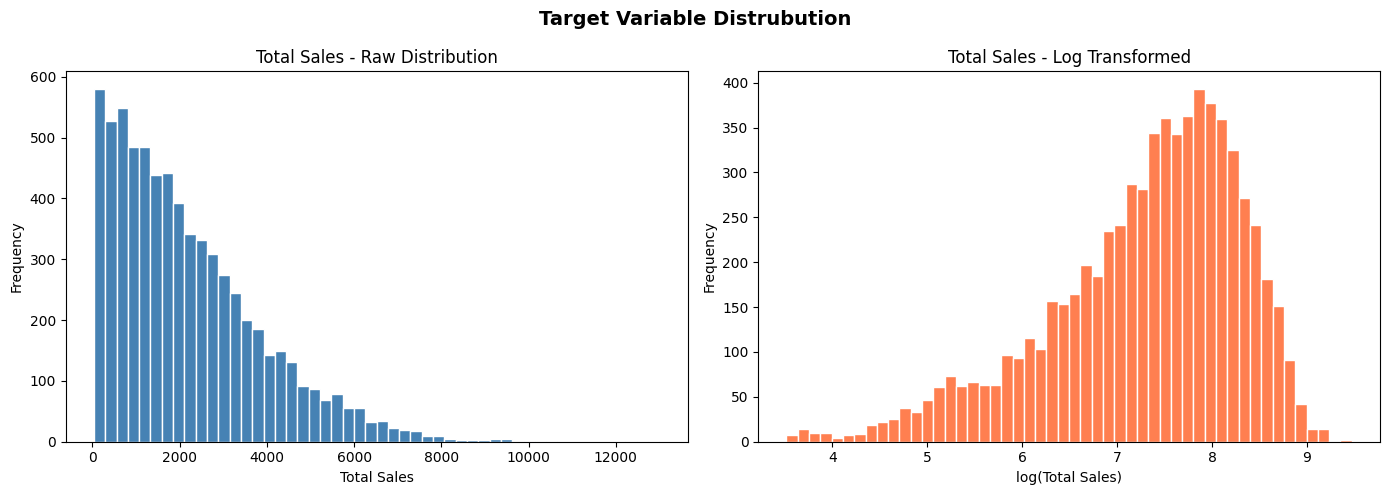

In [195]:
print("=" * 50)
print("       EXPLORATORY DATA ANALYSI")
print("=" * 50)

# Dataset Overview
dsn_train.info()

# Target Variable Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw Distribution
axes[0].hist(dsn_train['total_sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Total Sales - Raw Distribution')
axes[0].set_xlabel('Total Sales')
axes[0].set_ylabel('Frequency')

# Log-transformed Distribution
axes[1].hist(np.log1p(dsn_train['total_sales']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Total Sales - Log Transformed')
axes[1].set_xlabel('log(Total Sales)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Target Variable Distrubution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


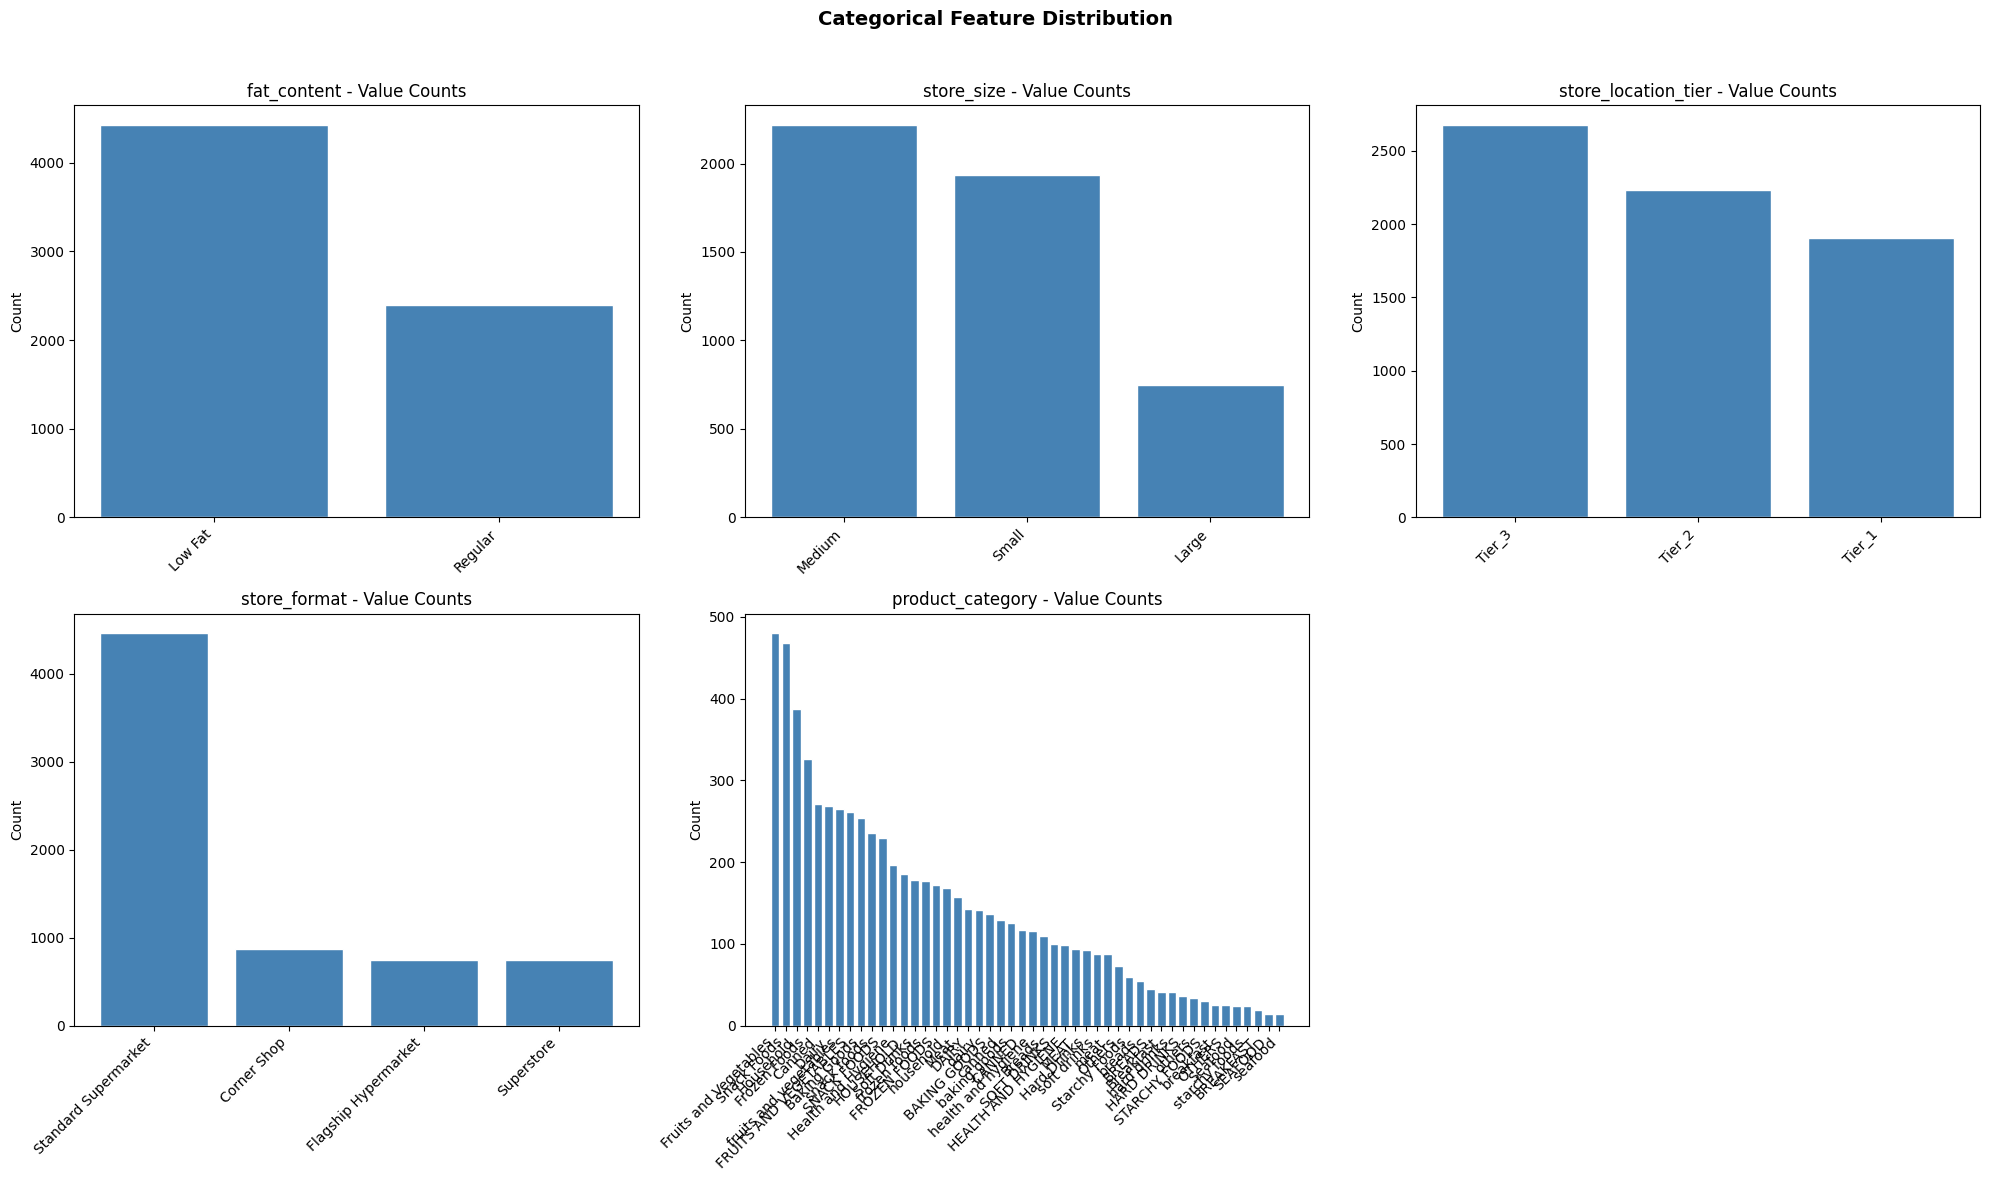

In [196]:
# Categorical Value Counts
cat_cols_eda = ['fat_content', 'store_size', 'store_location_tier',
                'store_format', 'product_category']
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, col in enumerate(cat_cols_eda):
    counts = dsn_train[col].value_counts()
    axes[idx].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    axes[idx].set_title(f'{col} - Value Counts')
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', labelrotation=45)
    for label in axes[idx].get_xticklabels():
        label.set_horizontalalignment('right')


# Hide the 6th emply subplot
axes[5].set_visible(False)

plt.suptitle('Categorical Feature Distribution', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

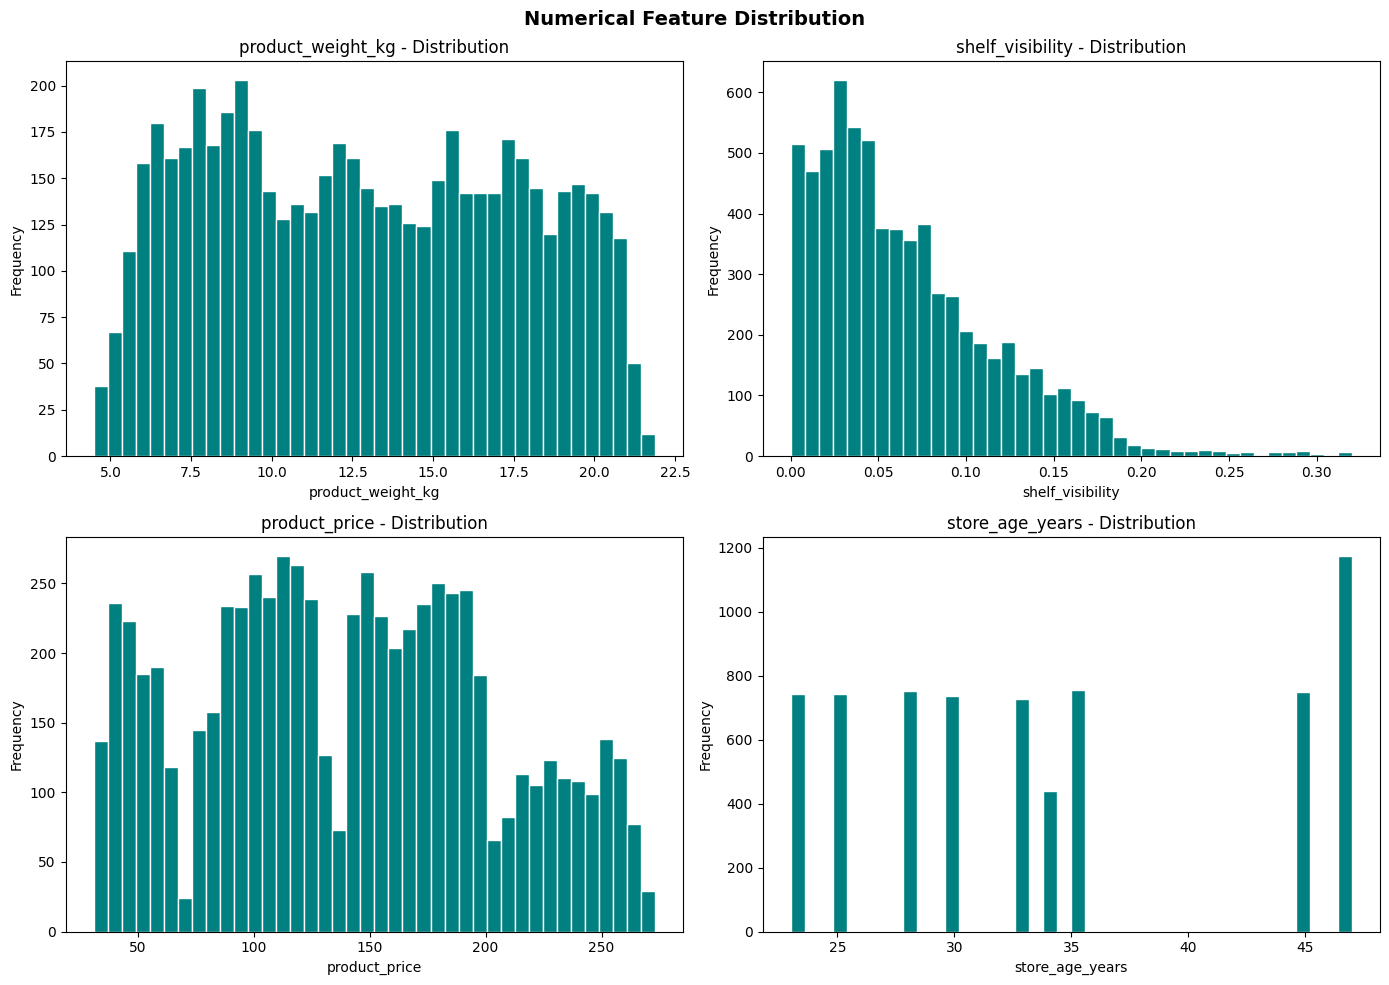

In [197]:
# Numerical Feature Distributions
num_cols = ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(num_cols):
    axes[idx].hist(dsn_train[col].dropna(), bins=40, color='teal', edgecolor='white')
    axes[idx].set_title(f'{col} - Distribution')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.suptitle('Numerical Feature Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

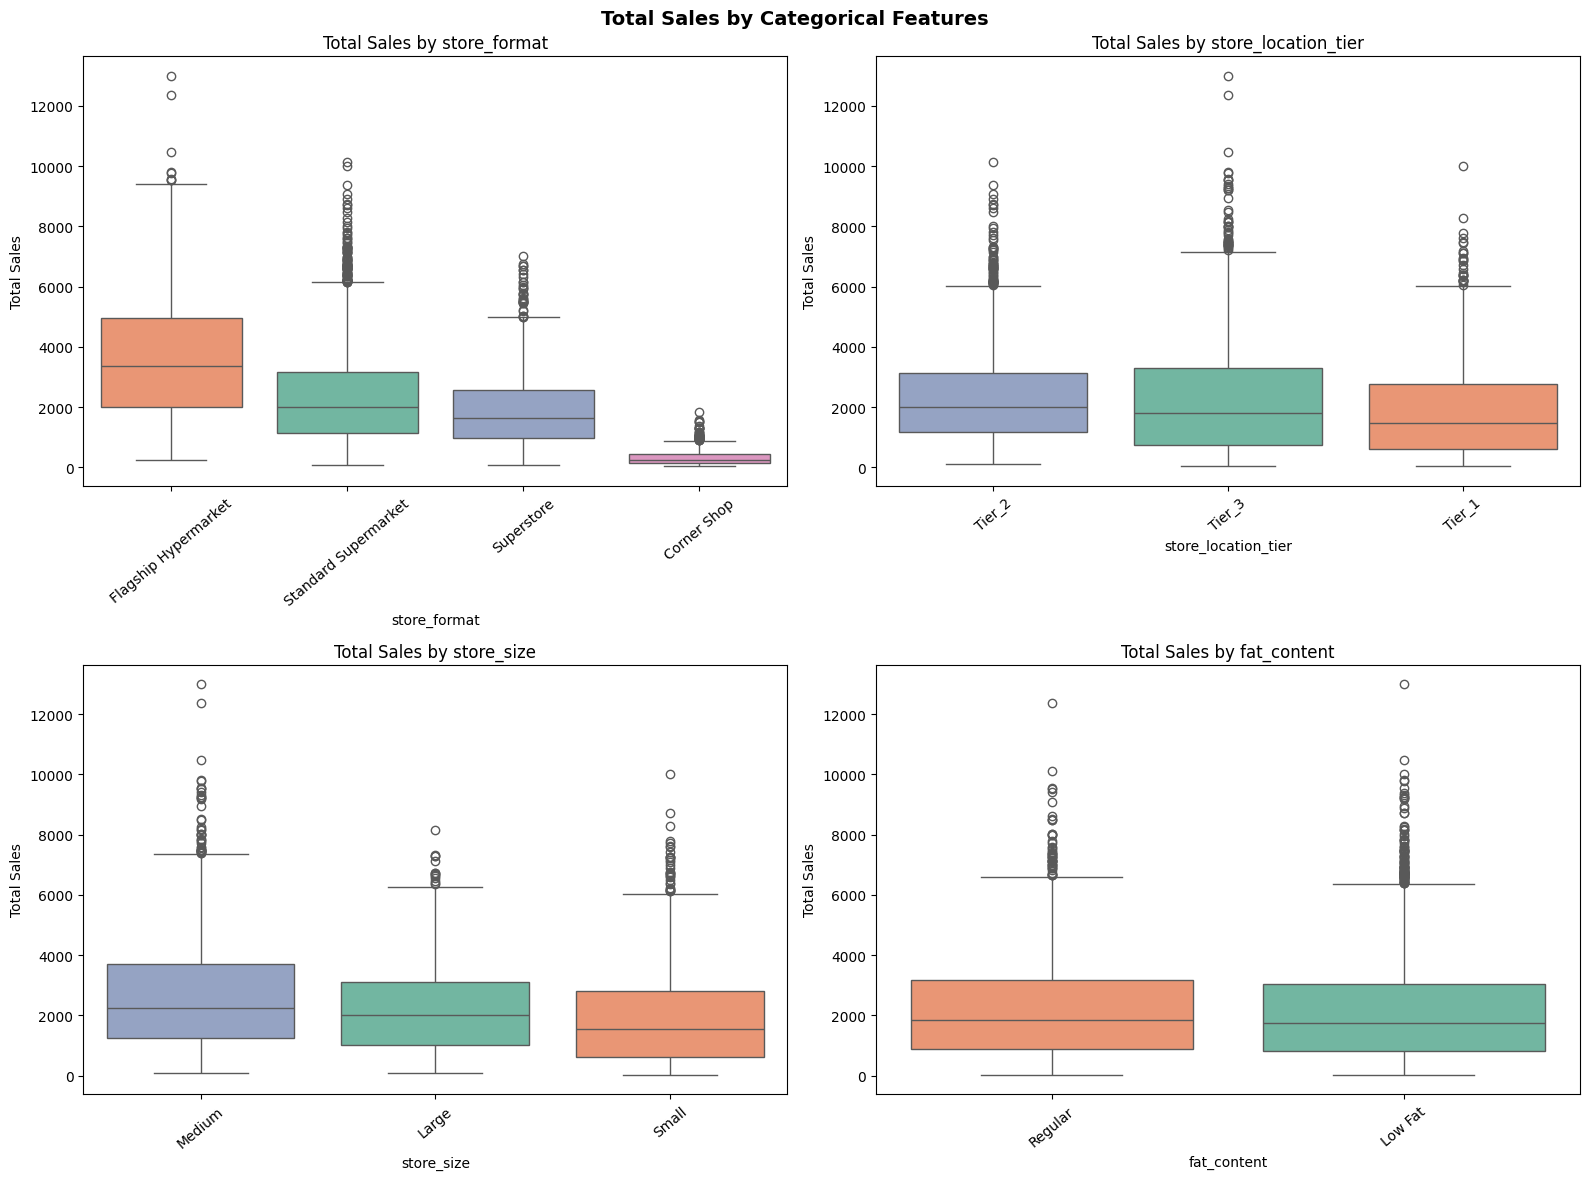

In [198]:
# Sales by Categorical Features
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

cat_vs_target = ['store_format', 'store_location_tier', 'store_size', 'fat_content']

for idx, col in enumerate(cat_vs_target):
    order = dsn_train.groupby(col)['total_sales'].median().sort_values(ascending=False).index
    sns.boxplot(data=dsn_train, x=col, y='total_sales', order=order,
               hue=col, palette='Set2', legend=False, ax=axes[idx])
    axes[idx].set_title(f'Total Sales by {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Total Sales')
    axes[idx].tick_params(axis='x', rotation=40)

plt.suptitle('Total Sales by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

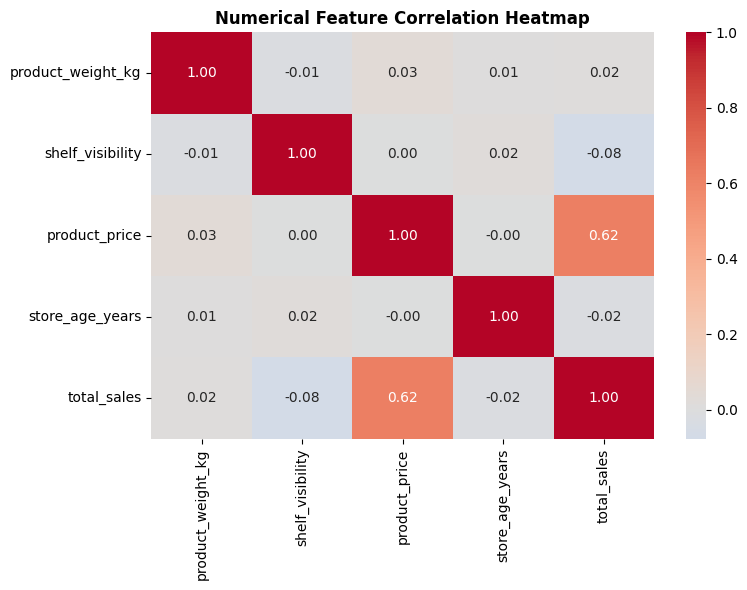

In [199]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
num_df = dsn_train[['product_weight_kg', 'shelf_visibility',
                   'product_price', 'store_age_years', 'total_sales']].dropna()
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Numerical Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

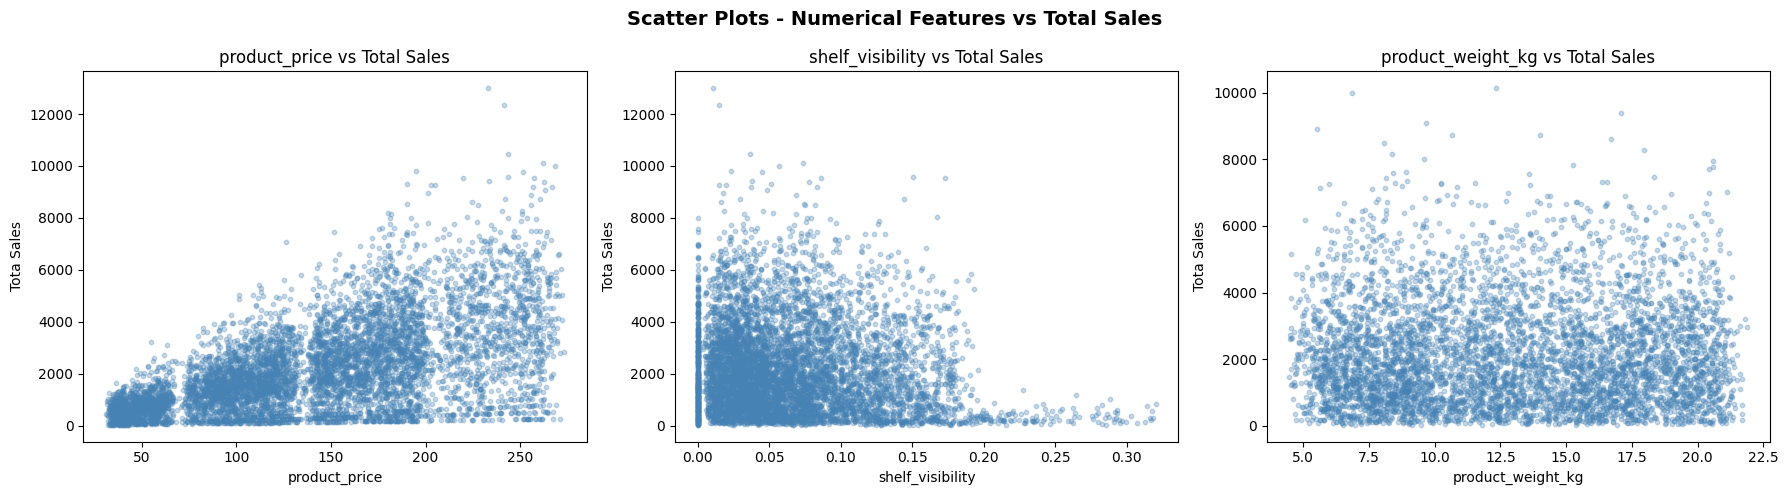

In [200]:
# Scatter Plots (Numerical vs Target)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter_cols = ['product_price', 'shelf_visibility', 'product_weight_kg']

for idx, col in enumerate(scatter_cols):
    axes[idx].scatter(dsn_train[col], dsn_train['total_sales'],
                     alpha=0.3, color='steelblue', s=10)
    axes[idx].set_title(f'{col} vs Total Sales')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Tota Sales')

plt.suptitle('Scatter Plots - Numerical Features vs Total Sales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

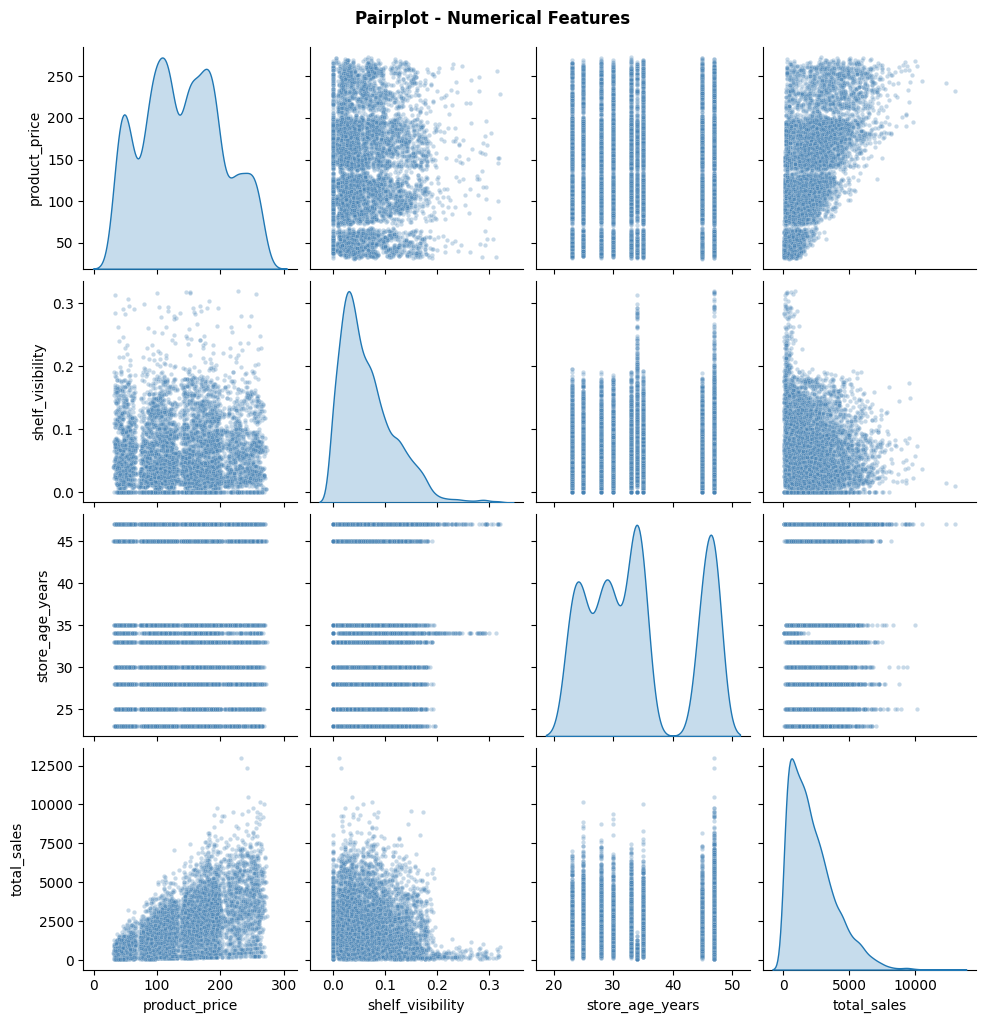

In [201]:
# Pairplot 
pairplot_df = dsn_train[['product_price', 'shelf_visibility',
                        'store_age_years', 'total_sales']].dropna()

g = sns.pairplot(pairplot_df, diag_kind='kde',
                plot_kws={'alpha': 0.3, 's': 10, 'color': 'steelblue'})

g.fig.suptitle('Pairplot - Numerical Features', y=1.02, fontweight='bold')
plt.show()

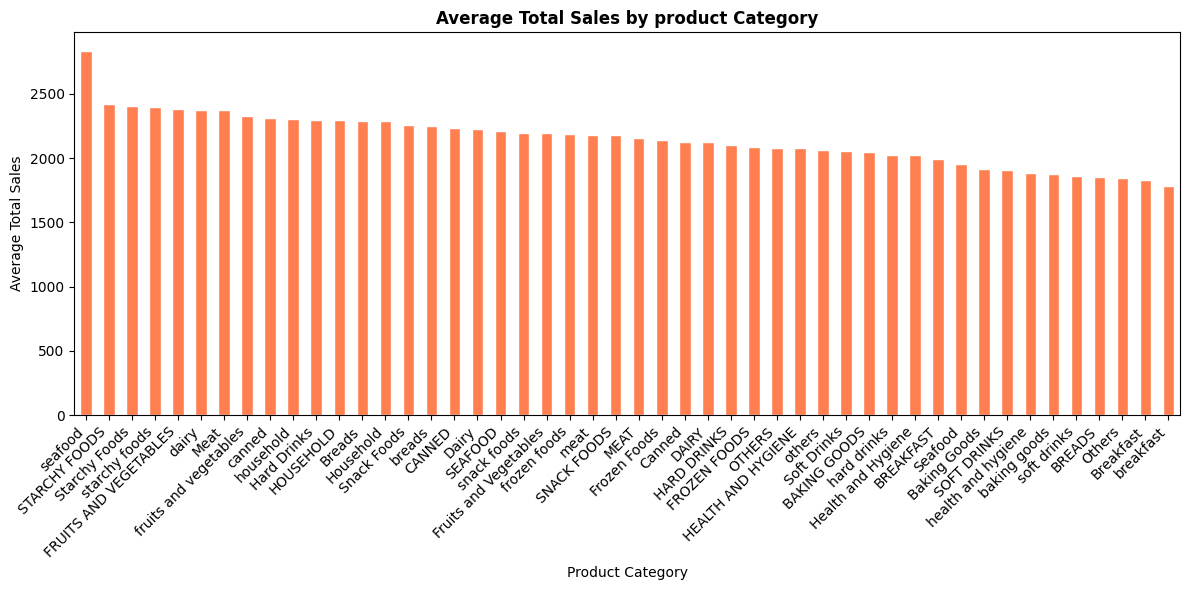

In [202]:
# Top Selling Product Categories
top_cats = dsn_train.groupby('product_category')['total_sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
top_cats.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Average Total Sales by product Category', fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Average Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

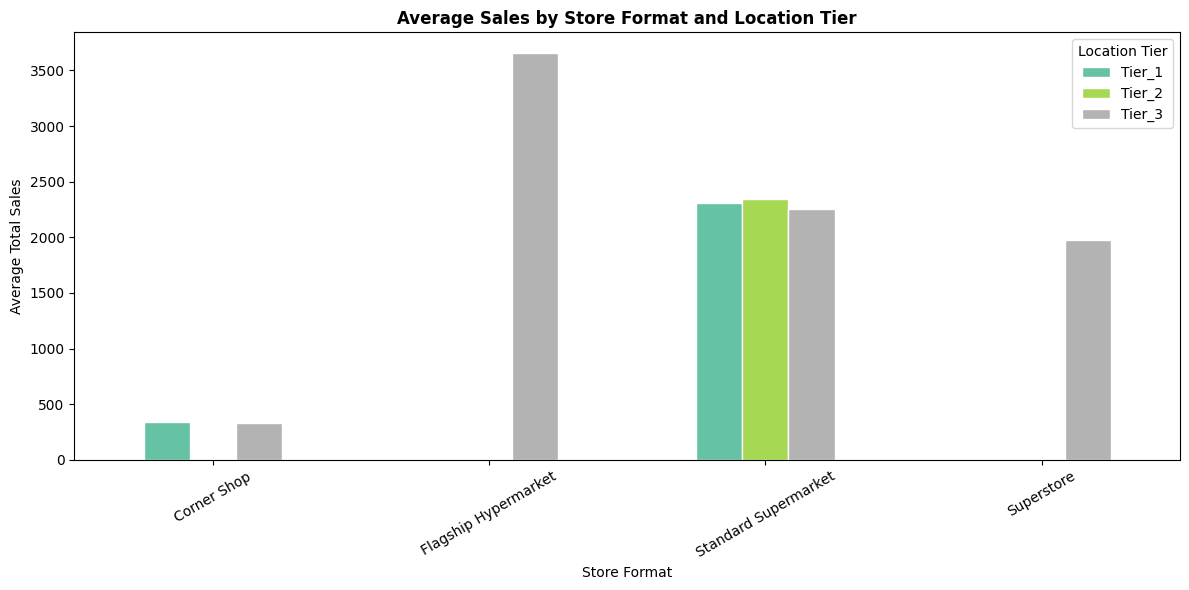


EDA Complete.


In [203]:
# Sales by Store Format and Location
plt.figure(figsize=(12, 6))
pivot = dsn_train.groupby(['store_format', 'store_location_tier'])['total_sales'].mean().unstack()
pivot.plot(kind='bar', colormap='Set2', edgecolor='white', figsize=(12, 6))
plt.title('Average Sales by Store Format and Location Tier', fontweight='bold')
plt.xlabel('Store Format')
plt.ylabel('Average Total Sales')
plt.xticks(rotation=30)
plt.legend(title='Location Tier')
plt.tight_layout()
plt.show()

print("\nEDA Complete.")
print("=" * 50)

**Feature Selection**

In [204]:
# Drop ID and Code Columns
drop_cols = ['id', 'product_code', 'store_code', 'total_sales', 'is_train']

# Split Back into Train and Test
dsn_train_df = df[df['is_train'] == 1].drop(columns=drop_cols)
dsn_test_df = df[df['is_train'] == 0].drop(columns=drop_cols)

print(f"\nFinal Train Shape: {dsn_train_df.shape}")
print(f"Final Test Shape: {dsn_test_df.shape}")
print(f"\nFeatures used: {dsn_train_df.columns.tolist()}")


Final Train Shape: (6818, 19)
Final Test Shape: (1705, 19)

Features used: ['product_weight_kg', 'fat_content', 'shelf_visibility', 'product_category', 'product_price', 'store_age_years', 'store_size', 'store_location_tier', 'store_format', 'price_per_kg', 'shelf_visibility_sq', 'price_vs_category_avg', 'store_est_year', 'store_age_bucket', 'product_avg_price', 'store_format_rank', 'store_tier_rank', 'price_x_visibility', 'format_x_tier']


In [205]:
# Define X and Y
X = dsn_train_df
y = dsn_target

# Log transform target (reduces RMSE sensitivity to large outliers)
y_log = np.log1p(y)

print(f"\ny range: {y.min():.2f} - {y.max():.2f}")
print(f"y_log range: {y_log.min():.2f} - {y_log.max():.2f}")


y range: 32.70 - 12996.82
y_log range: 3.52 - 9.47


**Model Training**

In [206]:
# Train / Validaation Split
X_dsn_train, X_val, y_dsn_train, y_val = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print(f"\nX_dsn_train: {X_dsn_train.shape}")
print(f"X_val:       {X_val.shape}")


X_dsn_train: (5454, 19)
X_val:       (1364, 19)


In [207]:
# Train XGBOOST (Main Model)
print("\n- Training XGBoost -")
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='rmse'
)

xgb_model.fit(
    X_dsn_train, y_dsn_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

xgb_val_pred = np.expm1(xgb_model.predict(X_val))
xgb_rmse = np.sqrt(mean_squared_error(np.expm1(y_val), xgb_val_pred))
print(f"\nXGBoost Validation RMSE: {xgb_rmse:.4f}")

print("Best iteartion:", xgb_model.best_iteration)
print("Best validation RMSE:", xgb_model.best_score)


- Training XGBoost -
[0]	validation_0-rmse:0.98910
[100]	validation_0-rmse:0.52359
[120]	validation_0-rmse:0.52503

XGBoost Validation RMSE: 1131.4782
Best iteartion: 70
Best validation RMSE: 0.5218382925647138


In [208]:
# Inspecting the learning curve
results = xgb_model.evals_result()

val_rmse = results['validation_0']['rmse']

print("Number of boosting rounds:", len(val_rmse))
print("Best iteration:", xgb_model.best_iteration)
print("Best RMSE:", min(val_rmse))

Number of boosting rounds: 121
Best iteration: 70
Best RMSE: 0.5218382925647138


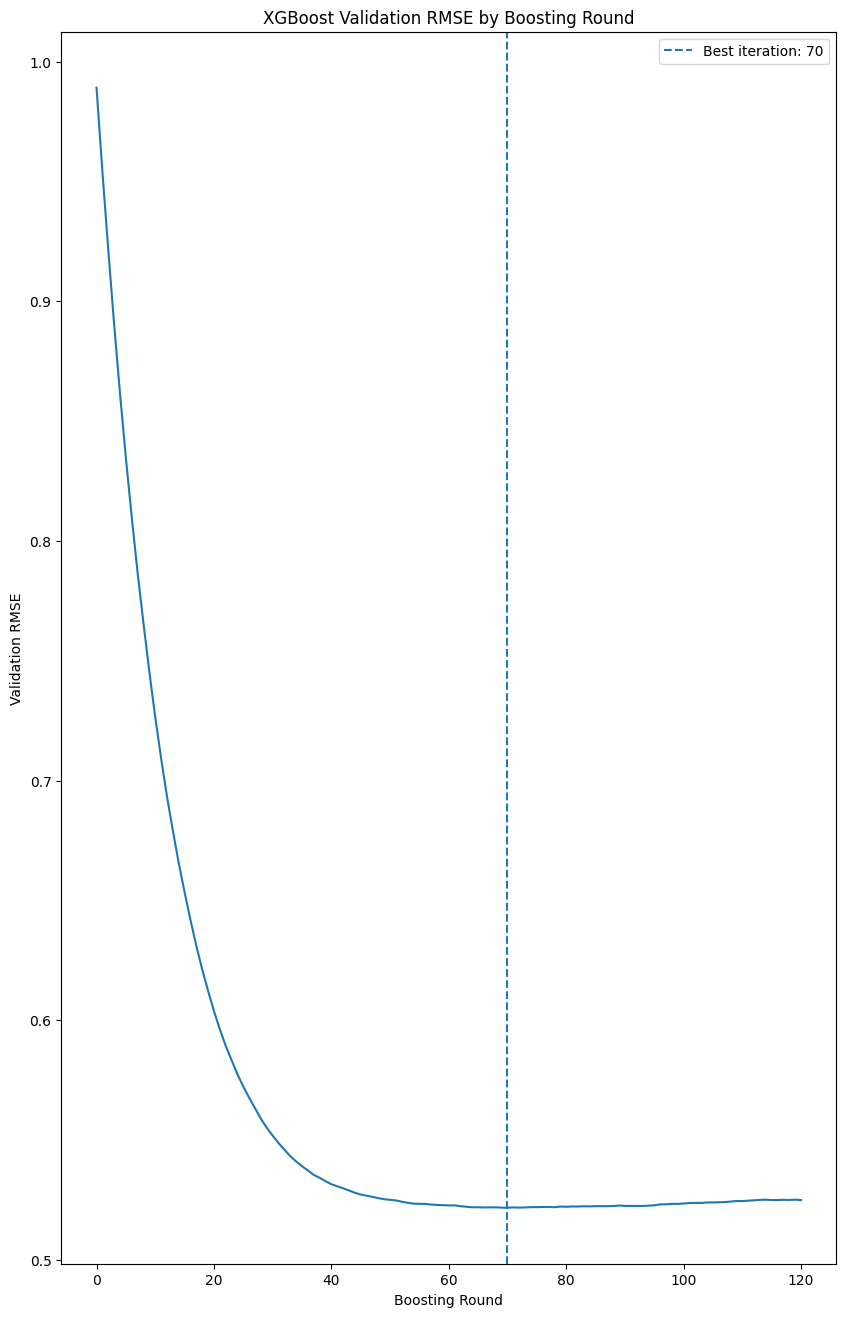

In [209]:
# Plotting the curve
plt.figure(figsize=(10, 16))
plt.plot(val_rmse)
plt.xlabel('Boosting Round')
plt.ylabel('Validation RMSE')
plt.title('XGBoost Validation RMSE by Boosting Round')

plt.axvline(
    x=xgb_model.best_iteration,
    linestyle='--',
    label=f'Best iteration: {xgb_model.best_iteration}'
)

plt.legend()
plt.tight_layout
plt.show()

In [210]:
# Train LightGBM
print("\n- Training LightGBM -")
lgbm_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(
    X_dsn_train, y_dsn_train,
    eval_set=[(X_val, y_val)]
)

lgbm_val_pred =np.expm1(lgbm_model.predict(X_val))
lgbm_rmse = np.sqrt(mean_squared_error(np.expm1(y_val), lgbm_val_pred))
print(f"LightGBM Validation RMSE: {lgbm_rmse:.4f}")


- Training LightGBM -
LightGBM Validation RMSE: 1180.1427


**Esemble Predictions**

In [211]:
# Ensemble Predictions
print("\n- Ensembling -")
# Weight XGBoost more if it performs better
val_ensemble = (xgb_val_pred * 0.6) + (lgbm_val_pred *0.4)
ensemble_rmse = np.sqrt(mean_squared_error(np.expm1(y_val), val_ensemble))
print(f"Ensemble Validation RMSE: {ensemble_rmse:.4f}")


- Ensembling -
Ensemble Validation RMSE: 1134.7922


**Model Comparison**

In [212]:
# Model Comparison
print("\n" + "=" * 40)
print("       MODEL COMPARSION")
print("=" * 40)
print(f" XGBoost RMSE : {xgb_rmse:.4f}")
print(f" LightGBM RMSE : {lgbm_rmse:.4f}")
print(f" Ensemble RMSE : {ensemble_rmse:.4f}")
print("=" * 40)


       MODEL COMPARSION
 XGBoost RMSE : 1131.4782
 LightGBM RMSE : 1180.1427
 Ensemble RMSE : 1134.7922


**Retrain on Full Training Data**

In [213]:
# Retrain on full training data
print("\n- Retraining on full training data -")

xgb_final = XGBRegressor(
    n_estimators=xgb_model.best_iteration,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
xgb_final.fit(X, y_log)

lgbm_final = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_final.fit(X, y_log)

print("Full retraining complete!")


- Retraining on full training data -
Full retraining complete!


**Predict on Test Data**

In [214]:
# Predict on Test Data
xgb_test_pred = np.expm1(xgb_final.predict(dsn_test_df))
lgbm_test_pred = np.expm1(lgbm_final.predict(dsn_test_df))

# Ensemble final predictions
final_predictions = (xgb_test_pred * 0.6) + (lgbm_test_pred * 0.4)

print(f"\nTest predictions range: {final_predictions.min():.2f} - {final_predictions.max():.2f}")
print(f"Test predictions mean: {final_predictions.mean():.2f}")



Test predictions range: 53.68 - 6585.36
Test predictions mean: 1946.64


**Feature Importance**


- Top 10 Feature Importance -
              Feature  Importance
    store_format_rank    0.404795
         store_format    0.371612
     store_age_bucket    0.053984
    product_avg_price    0.036792
        format_x_tier    0.036321
           store_size    0.027198
        product_price    0.021444
       store_est_year    0.012089
price_vs_category_avg    0.010909
      store_age_years    0.007619

Feature importance plot saved.


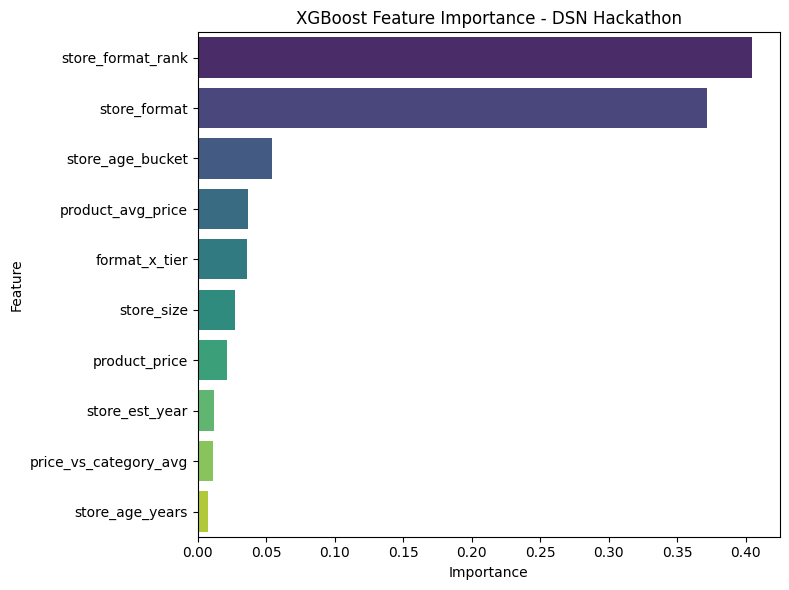

In [215]:
# Feature importance
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_final.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n- Top 10 Feature Importance -")
print(feat_imp.head(10).to_string(index=False))

plt.figure(figsize=(8, 6))
sns.barplot(data=feat_imp.head(10), x='Importance', y='Feature',
           hue='Feature', palette='viridis', legend=False)
plt.title("XGBoost Feature Importance - DSN Hackathon")
plt.tight_layout()
plt.savefig("/kaggle/working/my_chart.png", dpi=120)
print("\nFeature importance plot saved.")

**Generate Submission File**

In [216]:
# Generatting submission file
submission = pd.DataFrame({
    'id':          dsn_test_ids.values,
    'total_sales': final_predictions,
})

submission.to_csv("/kaggle/working/submission(Sambo Bashir).csv", index=False)
print("\n Submission file saved!")
print(f"  Shape: {submission.shape}")
print(submission.head(10))


 Submission file saved!
  Shape: (1705, 2)
          id  total_sales
0  row_00009  2577.910497
1  row_00015  3946.811262
2  row_00019  2904.204702
3  row_00020  3025.203963
4  row_00023  2208.285887
5  row_00026   303.169135
6  row_00027  3558.299062
7  row_00033  2558.419471
8  row_00034   390.649071
9  row_00037  1686.404237
